# Notebook 2 — Build a prediction pipeline (common)

*Day 3 · everyone builds the same pipeline, measures the baseline, then forks to a tuning lab.*

In [1]:
# ======================================================================================
# Setup — run this first (you don't need to read it closely).
# It imports a few libraries, sets a shared plot style, and defines the helper functions used
# throughout the notebook (load_data, the plot helpers, the metric helpers, ...).  These are the
# SAME helpers in every notebook, so your results line up with your teammates'.  If a later cell
# says a helper is "not defined", you probably skipped this cell — run it, then carry on.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------
# Paths — resolved so the notebooks work whether they're run from the materials folder or
# from solutions/ .  Outputs and figures always land in the materials root.
# ----------------------------------------------------------------------------------------
def _materials_root():
    """Folder that contains data/ ; searched upward from the working directory."""
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "data")):
            return d
    return here

ROOT = _materials_root()
DATA_DIR = os.path.join(ROOT, "data")
OUTPUTS_DIR = os.path.join(ROOT, "outputs")
FIGURES_DIR = os.path.join(ROOT, "figures")
MODELS_DIR = os.path.join(ROOT, "models")     # fitted models saved to disk (experiment tracking)
for _d in (DATA_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR):
    os.makedirs(_d, exist_ok=True)

# Module-level cache of the reconstruction basis (set by load_data; used by reconstruct_spectrum).
_RECON = {"wavelength": None, "basis": None, "is_mock": True, "Xerr": None}
_RAW_CACHE = {}   # path -> full arrays, so repeated load_data() calls don't re-read the file

# Default working-set size.  The real catalog is ~200k stars; we train on a fast deterministic
# subsample by default so in-class fits stay quick AND every notebook sees the SAME stars (which
# keeps the NB2->NB3->NB4 saved-prediction hand-off aligned).  Pass n=None to use the WHOLE
# high-quality catalog (the "does more data help?" / label-transfer-at-scale exercise).
DEFAULT_N = 30000

# Canonical label columns.  The modelling track predicts [Fe/H]; Teff & logg are explored and
# used as the axes for residual / coverage maps.  alpha/age/dist are extra "explore" labels.
LABEL_COLS = ["Teff", "logg", "FeH", "alpha", "age", "dist"]
PRETTY = {"Teff": r"$T_\mathrm{eff}$ [K]", "logg": r"$\log g$ [dex]",
          "FeH": r"[Fe/H] [dex]", "alpha": r"[$\alpha$/M] [dex]",
          "age": "age [Gyr]", "dist": "distance [pc]"}


# ========================================================================================
# Plot style
# ========================================================================================
def set_plot_style():
    """Consistent, readable matplotlib defaults.  Called once in setup."""
    plt.rcParams.update({
        "figure.figsize": (6.4, 4.4), "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "font.size": 12, "axes.titlesize": 13,
        "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.25,
        "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 11, "lines.linewidth": 2.0,
        "scatter.edgecolors": "none", "image.cmap": "viridis",
    })

# A small colour-blind-friendly palette used across the materials for named series.
COLORS = {"linear": "#888888", "knn": "#0072B2", "rf": "#009E73",
          "nn": "#D55E00", "native": "#0072B2", "conformal": "#D55E00",
          "truth": "#222222", "accent": "#CC79A7"}


# ========================================================================================
# Data loading  (the mock generator lives here so the shipped npz and the on-the-fly
# fallback are guaranteed identical)
# ========================================================================================
_C2_NM = 1.438777e7  # second radiation constant hc/k in nm*K


def _build_basis(wave_min=336.0, wave_max=1020.0, n_wave=343, n_bp=55, n_rp=55):
    """Smooth windowed-cosine modes per band, orthonormalised.  Low modes are broad
    (continuum), high modes wiggly (fine structure).  reconstruct = B @ coeff."""
    wave = np.linspace(wave_min, wave_max, n_wave)
    cols = []
    def band(lo, hi, n_modes):
        x = (wave - lo) / (hi - lo)
        win = np.where((x >= 0) & (x <= 1), np.sin(np.clip(x, 0, 1) * np.pi) ** 0.5, 0.0)
        for j in range(n_modes):
            cols.append(np.cos(j * np.pi * np.clip(x, 0, 1)) * win)
    band(wave_min, 690.0, n_bp)
    band(630.0, wave_max, n_rp)
    Q, _ = np.linalg.qr(np.column_stack(cols))
    return wave, Q[:, :n_bp + n_rp]


def _synthesize_mock(n=50000, seed=42):
    """
    # MOCK DATA — swap for the real Zenodo loader.
    Physically-motivated synthetic stand-in for the Laroche & Speagle APOGEE x Gaia-XP
    cross-match.  Returns the same dict that the shipped npz stores.  See the build spec
    and _build/make_mock_dataset.py for the full rationale.  In one sentence: a Planck
    continuum sets Teff; Balmer lines reinforce Teff; gravity-sensitive molecular bands
    carry log g; SHALLOW metal lines (suppressed at high Teff) carry the hard, heteroscedastic
    [Fe/H]; reddening + hidden factors add a realistic irreducible (aleatoric) floor.
    """
    rng = np.random.default_rng(seed)
    wave, B = _build_basis()
    W = wave.size

    # --- labels with Kiel-diagram structure: dwarfs + giants + red clump + metal-poor halo ---
    is_giant = rng.random(n) < 0.45
    Teff = np.empty(n); logg = np.empty(n); FeH = np.empty(n)
    nd, ng = np.count_nonzero(~is_giant), np.count_nonzero(is_giant)
    Td = 4000 + 3100 * rng.beta(1.5, 2.5, nd)
    Teff[~is_giant] = Td
    logg[~is_giant] = 4.62 - 0.00013 * (Td - 4500) + rng.normal(0, 0.10, nd)
    FeH[~is_giant] = rng.normal(-0.05, 0.25, nd)
    Tg = 3800 + 1700 * rng.beta(2.0, 2.3, ng)
    Teff[is_giant] = Tg
    logg[is_giant] = 1.7 + 0.00095 * (Tg - 3800) + rng.normal(0, 0.33, ng)
    FeH[is_giant] = rng.normal(-0.28, 0.34, ng)
    clump = is_giant & (rng.random(n) < 0.33); nc = np.count_nonzero(clump)
    Teff[clump] = rng.normal(4800, 140, nc); logg[clump] = rng.normal(2.45, 0.11, nc)
    FeH[clump] = rng.normal(-0.10, 0.20, nc)
    halo = rng.random(n) < 0.06; nh = np.count_nonzero(halo)
    Teff[halo] = rng.normal(4900, 450, nh)
    logg[halo] = np.clip(rng.normal(2.2, 0.7, nh), 0.5, 3.6)
    FeH[halo] = rng.normal(-1.45, 0.45, nh)
    is_giant = is_giant | halo
    Teff = np.clip(Teff, 3500, 7600); logg = np.clip(logg, 0.3, 5.0); FeH = np.clip(FeH, -2.4, 0.55)
    alpha = np.clip(0.13 - 0.24 * FeH + rng.normal(0, 0.035, n), -0.05, 0.5)
    age = np.clip(2.0 + 6.5 * is_giant - 3.5 * FeH + rng.normal(0, 1.8, n), 0.3, 13.5)
    dist = np.exp(rng.normal(6.7, 0.9, n)) * (1.0 + 1.5 * is_giant)

    # --- forward model: labels -> flux ---
    def gauss(c, w): return np.exp(-0.5 * ((wave - c) / w) ** 2)
    x = _C2_NM / (wave[None, :] * Teff[:, None])
    flux = wave[None, :] ** -5 / np.expm1(np.clip(x, 1e-6, 700))
    flux = flux / flux.mean(axis=1, keepdims=True)
    jump = 1.0 / (1.0 + np.exp((wave - 382.0) / 6.0))
    flux *= 1.0 - (0.18 * np.clip((Teff - 5200) / 2500, 0, 1.4) * (1 + 0.15 * (4.5 - logg)))[:, None] * jump[None, :]
    balmer = sum(a * gauss(c, 9.0) for c, a in [(434., .9), (486.1, 1.1), (656.3, 1.)])
    bstr = np.clip(np.exp((Teff - 5200) / 1500), 0.15, 6.0) * (1 + 0.12 * (4.5 - logg))
    flux *= 1.0 - 0.012 * bstr[:, None] * balmer[None, :]
    g_dwarf = np.clip(logg - 3.0, 0, 2.0)[:, None]; g_giant = np.clip(3.6 - logg, 0, 3.2)[:, None]
    coolf = np.clip((5500 - Teff) / 2000.0, 0.2, 1.4)[:, None]
    grav = np.zeros((n, W))
    for c, a in [(488., 1.), (521., .9), (692., .8)]: grav += a * g_dwarf * gauss(c, 15.)[None, :]
    for c, a in [(421., .9), (793., .8), (883., 1.)]: grav += a * g_giant * gauss(c, 17.)[None, :]
    flux *= 1.0 - 0.038 * coolf * grav
    metal = sum(a * gauss(c, 11.0) for c, a in
                [(422.7, 1.), (460., .7), (517.3, 1.2), (527., .9), (589.3, 1.1),
                 (670.8, .6), (770., .6), (850., .8), (920., .5)])
    # Line depth scales with metal abundance (metal-poor stars have WEAK lines -> little [Fe/H]
    # information -> the dominant, physically-correct source of heteroscedastic [Fe/H] error).
    # Temperature only mildly suppresses lines; gravity gives luminous giants slightly weaker,
    # more variable lines (they are also the sparsest, most-extrapolated regime).
    mstr = 10.0 ** (0.55 * FeH)
    tsupp = np.clip(np.exp(-(Teff - 4500) / 4800.0), 0.6, 1.25)
    line_amp = (mstr * tsupp * np.clip(0.7 + 0.22 * logg, 0.7, 1.4))[:, None]
    flux *= 1.0 - 0.045 * line_amp * metal[None, :]
    ebv = np.abs(rng.normal(0, 0.11, n))[:, None]
    ext = (550.0 / wave) ** 1.0
    flux *= 10.0 ** (-0.4 * 1.6 * ebv * (ext / ext.mean())[None, :])
    P = np.column_stack([np.sin(f * np.pi * (wave - wave[0]) / (wave[-1] - wave[0])) for f in (1.5, 3.5, 6.5)])
    flux *= 1.0 + 0.004 * (rng.normal(0, 1, (n, 3)) @ P.T)
    gflux = np.exp(rng.normal(0.0, 0.8, n))
    snr = np.clip(58 * gflux ** 0.30 * np.exp(rng.normal(0, 0.30, n)), 20, 400)
    obs = gflux[:, None] * np.clip(flux, 1e-3, None)
    noise_std = obs.mean(axis=1, keepdims=True) / snr[:, None]        # photon-noise std (per star)
    obs = obs + rng.normal(0, 1, obs.shape) * noise_std
    X = (obs @ B).astype(np.float32)
    # per-coefficient measurement error on the RAW coefficients (the orthonormal basis preserves the
    # per-component noise std) — used by the NB3 input-Monte-Carlo stretch.
    Xerr = np.repeat(noise_std, 110, axis=1).astype(np.float32)
    return dict(X=X, Xerr=Xerr, Teff=Teff, logg=logg, FeH=FeH, alpha=alpha, age=age, dist=dist,
                snr=snr, gflux=gflux, source_id=(1_000_000_000 + np.arange(n)),
                wavelength=wave, basis=B.astype(np.float32), is_mock=True)


def load_data(path=None, n=DEFAULT_N, seed=0, verbose=True):
    """
    Load the dataset in one line:  X, y, meta = load_data()

    Parameters
    ----------
    n    : working-set size.  Returns a deterministic random subsample of `n` stars (default
           DEFAULT_N=30000) so fits are fast and every notebook sees the same stars.  Pass
           `n=None` to use the ENTIRE high-quality catalog (the scale-up exercise) — slower.
    seed : seed for the subsample (keep it fixed so the NB2->NB3->NB4 hand-off stays aligned).

    Returns
    -------
    X    : float array, shape (n, 110) — the Gaia XP coefficients (55 BP + 55 RP).
    y    : DataFrame with columns Teff, logg, FeH (+ alpha, dist) — the labels.
    meta : DataFrame with source_id, snr, gflux — per-star bookkeeping (gflux is the
           brightness scale used by normalize_by_g).
    """
    if path is None:
        for cand in ("xp_apogee_real.npz", "xp_apogee_mock.npz"):
            p = os.path.join(DATA_DIR, cand)
            if os.path.exists(p):
                path = p
                break
    key = path if path is not None else "__synth__"
    if key in _RAW_CACHE:
        data = _RAW_CACHE[key]
    elif path is not None and os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        data = {k: d[k] for k in d.files}
        _RAW_CACHE[key] = data
    else:
        if verbose:
            print("No data file found — synthesising the mock dataset on the fly.")
        data = _synthesize_mock()
        _RAW_CACHE[key] = data
    is_mock = bool(data.get("is_mock", True))
    src = os.path.basename(path) if path else "synthesised mock"

    _RECON["wavelength"] = np.asarray(data["wavelength"], float)
    _RECON["basis"] = np.asarray(data["basis"], float)
    _RECON["is_mock"] = is_mock

    X_all = np.asarray(data["X"], dtype=float)
    N = X_all.shape[0]
    if n is not None and n < N:
        sel = np.sort(np.random.default_rng(seed).permutation(N)[:n])
    else:
        sel = np.arange(N)
    X = X_all[sel]
    _RECON["Xerr"] = np.asarray(data["Xerr"], float)[sel] if "Xerr" in data else None  # for input-MC (NB3)
    y = pd.DataFrame({c: np.asarray(data[c], float)[sel] for c in LABEL_COLS if c in data})
    meta = pd.DataFrame({k: np.asarray(data[k]).ravel()[sel] for k in ("source_id", "snr", "gflux") if k in data})
    if verbose:
        tag = "MOCK (synthetic)" if is_mock else "REAL (Gaia XP x APOGEE)"
        extra = f" (subsampled from {N:,}; pass n=None for all)" if len(sel) < N else ""
        print(f"Loaded {src}: {tag}  —  {X.shape[0]:,} stars{extra}, {X.shape[1]} coefficients.")
    return X, y, meta


# ========================================================================================
# Spectrum reconstruction
# ========================================================================================
def load_input_errors():
    """Per-coefficient measurement errors for the stars from the LAST `load_data()` call (same rows,
    same order, same (n, 110) shape as the `X` you just loaded) — on the RAW coefficient scale.
    For the NB3 input-Monte-Carlo stretch:  X_perturbed = X + rng.normal(0, load_input_errors()).
    Returns None if the dataset has no stored errors (call `load_data()` first)."""
    if _RECON["Xerr"] is None:
        load_data(verbose=False)
    return _RECON["Xerr"]


def reconstruct_spectrum(coeffs):
    """
    Turn a star's 110 XP coefficients into a sampled spectrum: returns (wavelength_nm, flux).
    Accepts a single (110,) vector or an (M, 110) batch.

    On the shipped data this uses the stored smooth basis (B @ coeff) — no extra packages.

    # REAL DATA: with the genuine Gaia archive continuous representation you would instead
    # reconstruct with GaiaXPy, e.g.:
    #     from gaiaxpy import calibrate
    #     sampling = np.arange(336, 1021, 2.0)              # nm
    #     spectra, sampled_wl = calibrate(source_dataframe, sampling=sampling, save_file=False)
    # The stored basis is recovered from Zenodo's wavelength-space spectra at curation time
    # (see _build/prepare_real_data.py), so this helper stays identical for mock and real.
    """
    if _RECON["basis"] is None:
        load_data(verbose=False)
    B, wave = _RECON["basis"], _RECON["wavelength"]
    coeffs = np.asarray(coeffs, float)
    flux = coeffs @ B.T
    return wave, flux


# ========================================================================================
# Preprocessing recipe:  normalize by the G-band  ->  standardize (fit on train only)
# ========================================================================================
def normalize_by_g(X, g):
    """Divide each star's coefficients by its G-band brightness scale `g` (a column of meta).
    Removes brightness/distance and keeps the spectral SHAPE — what carries the labels."""
    g = np.asarray(g, float).reshape(-1, 1)
    return np.asarray(X, float) / g


def standardize(X_train, X_other):
    """Z-score the coefficients using statistics from the TRAINING set only, then apply the
    same shift/scale to another split.  Returns (X_train_scaled, X_other_scaled).
    (Equivalent to sklearn's StandardScaler fit on train; spelled out for clarity.)"""
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (X_train - mu) / sd, (X_other - mu) / sd


# ========================================================================================
# Splitting  (fixed seed so every student gets the same train / cal / test stars)
# ========================================================================================
def train_cal_test_split(X, y, seed=0, fracs=(0.6, 0.2, 0.2)):
    """Reproducible 60/20/20 split into train / calibration / test.
    Returns a dict with X_* arrays, y_* DataFrames, and idx_* index arrays.
    Calibration is held out for the uncertainty work in NB3/NB4."""
    X = np.asarray(X, float)
    y = y.reset_index(drop=True)
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_tr = int(fracs[0] * n); n_ca = int(fracs[1] * n)
    i_tr, i_ca, i_te = idx[:n_tr], idx[n_tr:n_tr + n_ca], idx[n_tr + n_ca:]
    return {
        "X_train": X[i_tr], "X_cal": X[i_ca], "X_test": X[i_te],
        "y_train": y.iloc[i_tr].reset_index(drop=True),
        "y_cal": y.iloc[i_ca].reset_index(drop=True),
        "y_test": y.iloc[i_te].reset_index(drop=True),
        "idx_train": i_tr, "idx_cal": i_ca, "idx_test": i_te,
    }


# ========================================================================================
# Models — the four estimators the students compare.  Defined ONCE here so NB2, NB3 and NB4
# build byte-identical models, which is what lets predictions and intervals line up across
# notebooks and across the three students.  Each is a Pipeline(StandardScaler + estimator),
# so you feed it the G-normalized coefficients and it standardizes internally (fit on train).
# ========================================================================================
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAMES = {"linear": "Linear regression (baseline)", "knn": "K-nearest neighbors",
               "rf": "Random forest", "nn": "Neural network (MLP)"}

def make_model(name, **overrides):
    """Canonical Pipeline(StandardScaler + estimator) for a model name in {linear,knn,rf,nn}.
    Pass overrides to tune one knob, e.g. make_model('knn', n_neighbors=20).  The step name for
    the estimator is its lowercased class name (e.g. 'kneighborsregressor') — handy in NB3 when
    you reach inside the fitted pipeline for a model-native uncertainty."""
    if name == "linear":
        est = LinearRegression(**overrides)
    elif name == "knn":
        est = KNeighborsRegressor(**{"n_neighbors": 12, **overrides})
    elif name == "rf":
        est = RandomForestRegressor(**{"n_estimators": 150, "min_samples_leaf": 3,
                                       "random_state": 0, "n_jobs": -1, **overrides})
    elif name == "nn":
        est = MLPRegressor(**{"hidden_layer_sizes": (64, 64), "alpha": 1e-3, "max_iter": 500,
                              "early_stopping": True, "random_state": 0, **overrides})
    else:
        raise ValueError(f"unknown model '{name}' (use one of {list(MODEL_NAMES)})")
    return make_pipeline(StandardScaler(), est)


# ========================================================================================
# Metrics
# ========================================================================================
def regression_metrics(y_true, y_pred):
    """Return a dict of RMSE, MAE, bias (mean signed error), and R^2."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2)) or 1.0
    return {"RMSE": float(np.sqrt(np.mean(err ** 2))), "MAE": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)), "R2": float(1.0 - ss_res / ss_tot)}


# ========================================================================================
# Plots — predictions & residuals
# ========================================================================================
def plot_pred_vs_true(y_true, y_pred, title=None, ax=None, color=None, label=None, units=""):
    """Scatter of predicted vs true with the 1:1 line and an RMSE annotation."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    if ax is None:
        _, ax = plt.subplots()
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    pad = 0.04 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1.3, zorder=1)
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=color or COLORS["rf"], label=label, zorder=2)
    m = regression_metrics(y_true, y_pred)
    ax.text(0.04, 0.96, f"RMSE = {m['RMSE']:.3g}{units}\nbias = {m['bias']:+.2g}{units}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.85))
    ax.set_xlabel(f"true{(' ' + units) if units else ''}")
    ax.set_ylabel(f"predicted{(' ' + units) if units else ''}")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    if label:
        ax.legend(loc="lower right")
    return ax


def plot_residuals(y_true, y_pred, feature=None, feature_name="value", ax=None, color=None):
    """Residuals (pred - true) vs the truth, or vs an external `feature` (e.g. Teff).
    A flat band around zero means well-behaved errors; trends/fans flag structure."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_pred - y_true
    xx = np.asarray(feature, float) if feature is not None else y_true
    xlabel = feature_name if feature is not None else "true value"
    if ax is None:
        _, ax = plt.subplots()
    ax.axhline(0.0, color="0.4", ls="--", lw=1.3, zorder=1)
    ax.scatter(xx, resid, s=8, alpha=0.35, color=color or COLORS["rf"], zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("residual (pred − true)")
    return ax


# ========================================================================================
# Uncertainty — coverage, reliability, comparison
# ========================================================================================
def empirical_coverage(y_true, lower, upper):
    """Fraction of true values that fall inside [lower, upper]."""
    y_true = np.asarray(y_true, float)
    return float(np.mean((y_true >= np.asarray(lower, float)) & (y_true <= np.asarray(upper, float))))


def plot_reliability(y_true, lower, upper, target=None, feature=None, feature_name="bin",
                     n_bins=8, ax=None, color=None, label=None):
    """
    'Are the error bars honest, everywhere?'  Bins the points (by an external `feature` such
    as Teff if given, else by the interval centre) and plots empirical coverage per bin against
    the `target` line.  Bars sitting below the target reveal where intervals under-cover.
    """
    y_true = np.asarray(y_true, float)
    lower = np.asarray(lower, float); upper = np.asarray(upper, float)
    inside = (y_true >= lower) & (y_true <= upper)
    xx = np.asarray(feature, float) if feature is not None else 0.5 * (lower + upper)
    if ax is None:
        _, ax = plt.subplots()
    edges = np.quantile(xx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers, cov = [], []
    for i in range(n_bins):
        m = (xx >= edges[i]) & (xx < edges[i + 1])
        if m.sum() >= 5:
            centers.append(xx[m].mean()); cov.append(inside[m].mean())
    ax.plot(centers, cov, "o-", color=color or COLORS["native"], label=label)
    if target is not None:
        ax.axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
    ax.set_xlabel(feature_name if feature is not None else "interval centre")
    ax.set_ylabel("empirical coverage")
    ax.set_ylim(0, 1.02)
    if target is not None or label:
        ax.legend(loc="lower center")
    return ax


def compare_intervals(y_true, intervals, target=None, ax=None):
    """
    Compare several named interval sets.  `intervals` maps name -> (lower, upper).
    Draws two bars per method — coverage and median width — and returns a tidy summary table.
    """
    y_true = np.asarray(y_true, float)
    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({"method": name, "coverage": empirical_coverage(y_true, lo, hi),
                     "median_width": float(np.median(np.asarray(hi, float) - np.asarray(lo, float)))})
    tbl = pd.DataFrame(rows).set_index("method")
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    names = list(tbl.index)
    cols = [COLORS.get(n.split()[0].lower(), COLORS["accent"]) for n in names]
    ax[0].bar(names, tbl["coverage"], color=cols)
    if target is not None:
        ax[0].axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
        ax[0].legend()
    ax[0].set_ylabel("empirical coverage"); ax[0].set_ylim(0, 1.02); ax[0].set_title("Coverage")
    ax[1].bar(names, tbl["median_width"], color=cols)
    ax[1].set_ylabel("median interval width"); ax[1].set_title("Sharpness (narrower is better)")
    for a in ax:
        a.tick_params(axis="x", rotation=20)
    return tbl


# ========================================================================================
# Small convenience used in worked examples
# ========================================================================================
def savefig(name, fig=None):
    """Save a figure into figures/ for reuse on the poster.  Returns the path."""
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt.gcf()).savefig(path)
    return path


def save_outputs(filename, **arrays):
    """Save named arrays into outputs/<filename> (the shared NB2->NB3->NB4 contract)."""
    path = os.path.join(OUTPUTS_DIR, filename)
    np.savez(path, **arrays)
    return path


def load_outputs(filename):
    """Load an outputs/ npz written by an earlier notebook; returns a dict of arrays."""
    d = np.load(os.path.join(OUTPUTS_DIR, filename), allow_pickle=True)
    return {k: d[k] for k in d.files}


# ----- Experiment tracking: save fitted models + log runs (so you can reproduce & compare) -----
def save_model(model, name):
    """Save a fitted model/pipeline to models/<name>.joblib. Returns the path.
    The point: a tuned model is an experiment result — persist it so NB3 can load the exact model
    you tuned (no silent refit), and so you can reproduce a run weeks later."""
    import joblib
    path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(model, path)
    return path


def load_model(name):
    """Load a model previously saved with save_model(...)."""
    import joblib
    return joblib.load(os.path.join(MODELS_DIR, f"{name}.joblib"))


def log_experiment(name, params, metrics, filename=None):
    """Append one experiment run (its hyper-parameters + its metrics) to a CSV and return the full
    log as a DataFrame. This is the bare-bones version of what tools like MLflow / Weights & Biases
    do: a durable, comparable record of 'what did I try, and how did it score?'.
      params  : dict of hyper-parameters, e.g. {'n_neighbors': 12, 'weights': 'distance'}
      metrics : dict of scores, e.g. {'cv_rmse': 0.21, 'test_rmse': 0.20}
    """
    path = os.path.join(OUTPUTS_DIR, filename or f"{name}_experiments.csv")
    row = {"run": 1, **{f"param_{k}": v for k, v in params.items()}, **metrics}
    if os.path.exists(path):
        prev = pd.read_csv(path)
        row["run"] = int(prev["run"].max()) + 1 if "run" in prev else len(prev) + 1
        log = pd.concat([prev, pd.DataFrame([row])], ignore_index=True)
    else:
        log = pd.DataFrame([row])
    log.to_csv(path, index=False)
    return log

set_plot_style()
print('Setup complete — helpers ready.')


Setup complete — helpers ready.


## Welcome — the day everyone builds the same pipeline

In Notebook 1 you got to know the data and noticed the errors weren't uniform — they were bigger for
some kinds of stars than others. Today the **whole team** does the same thing together: you turn that
data into a **model** — a rule that takes a star's 110 Gaia XP numbers and predicts its metallicity,
**[Fe/H]** — and you learn to measure how good that model really is.

This is the **common** notebook. Everyone runs it, top to bottom, today. It does three things:

1. **Lays down the ideas** — what a supervised model is, why we wrap it in a *pipeline*, and why we
   split the stars into train / calibration / test (so we can catch **overfitting**).
2. **Runs the complete pipeline once, on the simplest model — the linear baseline.** Load → preprocess
   → split → fit → predict → score → *look* at the diagnostic plots. We save those baseline
   predictions; every later notebook reads them.
3. **Sends you to your own tuning lab.** At the end is **the fork**: Student A opens `02a_tune_knn`,
   Student B opens `02b_tune_random_forest`, Student C opens `02c_tune_neural_net`. That's where each
   of you takes *one* model and tunes it deeply.

**We predict `[Fe/H]`** (metallicity). It is the *hardest* of the three stellar labels to read off a
low-resolution spectrum — which is exactly why careful evaluation, and next week's honest uncertainty,
matter. `Teff` (surface temperature) and `log g` (surface gravity) are *not* prediction targets here;
they come back as the **axes we slice the errors over** — the map of *where* the model does well and
badly.

> The grey **Setup** cell below has all the helpers. **Run it, don't read it.** Everything here runs
> top-to-bottom as shipped. At the very end you'll save the baseline to `outputs/` and `models/` —
> your tuning lab and Notebooks 3 and 4 pick them up from there.


In [2]:
# The tools this notebook uses (the Setup cell above already loaded the data/plot helpers).
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
# (DecisionTreeRegressor is imported locally in the overfitting demo, where it is used.)

print("Imports ready.")

Imports ready.


## 1 · What a supervised model is

**Supervised regression**, in one breath: we have examples where we already know the answer —
inputs **`X`** (the 110 XP coefficients per star) and a target **`y`** (here `[Fe/H]`). We learn a
function `f` so that `f(X) ≈ y`, then turn `f` loose on *new* stars we've never labelled.

A bit of vocabulary, defined on first use:

- **Feature** — one input number. We have 110 of them per star (the XP coefficients).
- **Target** (or **label**) — the answer we're trying to predict. Here it's `[Fe/H]`, a single number
  per star.
- **Regression** — the flavour of supervised learning where the target is a *continuous number* (a
  metallicity), not a category (like "dwarf vs. giant").
- **Generalization** — the only test that counts. The model never sees the true `[Fe/H]` of a new star,
  so to do well it has to have learned the real pattern, not memorized the training stars.

This is the deck's "110 coefficients in → a stellar label out," made concrete.


## 1.1 · X → f → y, and the pipeline of steps

The full path a star takes through our code:

> **raw 110 coefficients → preprocess → model fits & predicts → evaluate**

Two preprocessing steps (you met both in Notebook 1):

- **Normalize by the G-band.** Divide each star's coefficients by its overall brightness so we keep
  the spectral *shape* — which carries the labels — and throw away distance/brightness, which doesn't.
- **Standardize** (a.k.a. **z-score**): rescale all 110 coefficients to a comparable spread so no single
  coefficient dominates just because its raw numbers happen to be large.

To do the standardizing *safely* we use a scikit-learn **`Pipeline`**. A Pipeline bundles "standardize,
then model" into one object. When you call `.fit()`, the scaler learns its mean and scale from the
**training data only**; when you call `.predict()`, it reuses *exactly* those numbers.

Why bother? Because of **data leakage** — the silent killer of honest ML scores. If you compute the
standardizing statistics using the test stars, the model has secretly peeked at the answer key, and
your score comes out dishonestly good. The Pipeline makes leakage *impossible* here: the scaler never
touches the test stars during fitting. That is the whole point of using one — and it pays off doubly
inside cross-validation (your tuning lab), where hand-rolled standardization silently leaks.

*Reference:* [scikit-learn — Pipelines](https://scikit-learn.org/stable/modules/compose.html#pipeline).


## 1.2 · Train, calibration, test — and *why three*

We split the labelled stars into **three** groups, with a fixed random seed so the whole team (and the
solutions) gets the *same* split:

- **Train (~60%)** — the model fits on these.
- **Calibration (~20%)** — *held out today on purpose.* Next week you'll use it to size and check
  uncertainty intervals. We set it aside now so it's ready then.
- **Test (~20%)** — *untouched until the very end*, used once for an honest score.

Why hold data out at all? Because of **overfitting**: a model can memorize the training stars — even
their noise — and look brilliant on them, yet predict badly on stars it has never seen. A great training
score paired with a bad test score is the signature of overfitting. Holding data out is how we *catch*
it. The opposite failure is **underfitting**: a model too rigid to capture the real signal, bad on
*both* train and test.

In your tuning lab you'll turn a **hyperparameter** — essentially a *flexibility dial*. Too flexible →
overfit; too rigid → underfit. We'll always judge it on held-out data, never on the training set. The
next section makes overfitting concrete, so you'll recognise it the instant you see it tomorrow.

One honest expectation: `[Fe/H]` is the **hard** label. Low-resolution XP spectra carry only shallow
metallicity information, so don't expect a tiny error — and that difficulty is precisely why the project
is interesting. (See Laroche & Speagle 2025, [arXiv:2404.07316](https://arxiv.org/abs/2404.07316).)


## 1.3 · A first look at overfitting — see it before you fight it

Overfitting is easier to *recognise* than to define, so let's make it appear. We'll fit two models on
the same training stars and score **both** on the training set *and* on the held-out test set:

- a **deliberately over-flexible** model — a single **decision tree** grown with no depth limit
  (`max_depth=None`). Left unchecked, a tree keeps splitting until every training star sits in its own
  leaf — so it can memorize the training answers *exactly*.
- the **linear baseline** — a rigid model that can only draw a (hyper)plane through the data.

A **decision tree** is a flowchart of yes/no questions on the coefficients ("is coefficient 7 above
0.3? then go left…"); each leaf predicts the average `[Fe/H]` of the training stars that land in it. One
unconstrained tree is the textbook over-fitter — perfect for this demo. (It's also the building block of
the random forest one of you will tune tomorrow, where *averaging many* trees tames exactly this
problem.)

Watch the **train vs. test** gap. That gap — not the test number alone — *is* overfitting.


In [3]:
# Load -> normalize-by-G -> split. (We'll reuse `sp` for the rest of the notebook.)
X, y, meta = load_data()
print("X:", X.shape, "| labels:", list(y.columns))

Xn = normalize_by_g(X, meta["gflux"])          # physics step: divide out brightness, keep spectral SHAPE
sp = train_cal_test_split(Xn, y, seed=0)        # fixed seed -> the SAME stars for the whole team
print("train / cal / test sizes:",
      sp["X_train"].shape[0], sp["X_cal"].shape[0], sp["X_test"].shape[0])

target = "FeH"                                   # our prediction target is metallicity
y_train = sp["y_train"][target].to_numpy()
y_cal   = sp["y_cal"][target].to_numpy()
y_test  = sp["y_test"][target].to_numpy()

Loaded xp_apogee_real.npz: REAL (Gaia XP x APOGEE)  —  30,000 stars (subsampled from 263,722; pass n=None for all), 110 coefficients.
X: (30000, 110) | labels: ['Teff', 'logg', 'FeH', 'alpha', 'dist']
train / cal / test sizes: 18000 6000 6000


In [4]:
# Import the over-flexible model locally (it is used only in this demo).
from sklearn.tree import DecisionTreeRegressor

# Two models, fit on the SAME training stars. Each is wrapped in the standardize->model Pipeline.
demo_models = {
    "deep tree (max_depth=None)": Pipeline([("scaler", StandardScaler()),
                                            ("model",  DecisionTreeRegressor(max_depth=None, random_state=0))]),
    "linear baseline":            Pipeline([("scaler", StandardScaler()),
                                            ("model",  LinearRegression())]),
}

print(f"{'model':<28}{'train R2':>10}{'test R2':>10}{'train RMSE':>12}{'test RMSE':>12}")
for name, pipe in demo_models.items():
    pipe.fit(sp["X_train"], y_train)
    tr = regression_metrics(y_train, pipe.predict(sp["X_train"]))   # scored on the TRAINING stars
    te = regression_metrics(y_test,  pipe.predict(sp["X_test"]))    # scored on the held-out TEST stars
    print(f"{name:<28}{tr['R2']:>10.3f}{te['R2']:>10.3f}{tr['RMSE']:>12.3f}{te['RMSE']:>12.3f}")

model                         train R2   test R2  train RMSE   test RMSE


deep tree (max_depth=None)       1.000     0.410       0.000       0.265


linear baseline                  0.625     0.580       0.214       0.223


*Caption: the deep tree scores a near-**perfect** train R² (it memorized the training stars) but a **mediocre** test R² — the big train≫test gap *is* overfitting. The linear baseline's train and test scores sit close together: it can't memorize, so it doesn't fool itself. A model that looks flawless on its training data has told you almost nothing.*

## 2 · The baseline pipeline, step by step

Now we run the *entire* pipeline once, on the simplest sensible model: **linear regression**, which
predicts `[Fe/H]` as a weighted sum of the 110 coefficients. Simple, fast, and the **baseline** — the
bar every fancier model has to clear. *Every* student's tuned model, tomorrow, will be measured against
this exact number.

We've already loaded, normalized, and split above. The next cells finish the path: **build
`Pipeline(StandardScaler + LinearRegression)` → fit → predict on test → metrics → two diagnostic
plots.** Read the comments, run each cell, and watch the numbers and plots appear.

We use the project's `make_model(...)` factory to build the pipeline. It returns exactly
`Pipeline(StandardScaler + LinearRegression)` — the same object spelled out by hand in §1.3 — so the
baseline you build here is byte-identical to the one your tuning lab and Notebooks 3–4 rebuild.

*Reference:*
[LinearRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).


In [5]:
# Build the baseline with the canonical factory: Pipeline(StandardScaler + LinearRegression).
# (make_model("linear") == the hand-spelled pipeline from section 1.3 — same scaler, same estimator.)
linear_pipe = make_model("linear")
print("baseline pipeline:", linear_pipe)

# Fit on the TRAINING split only, then predict [Fe/H] for the held-out TEST stars.
linear_pipe.fit(sp["X_train"], y_train)
y_test_pred = linear_pipe.predict(sp["X_test"])
print("predicted", y_test_pred.shape[0], "test stars; first 5:", y_test_pred[:5].round(3))

baseline pipeline: Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearregression', LinearRegression())])


predicted 6000 test stars; first 5: [ 0.364 -0.338 -0.611 -0.588 -0.496]


*Caption: one `.fit()` learns the scaler **and** the linear weights together; `.predict()` reuses them — leakage-free by construction, because the scaler never saw the test stars.*

In [6]:
# Four standard numbers. RMSE / MAE = typical error size (in dex); bias = mean over/under-shoot;
# R2 = fraction of variance explained (1.0 is perfect, 0.0 is no better than guessing the mean).
linear_metrics = regression_metrics(y_test, y_test_pred)
for k, v in linear_metrics.items():
    print(f"{k:>5}: {v: .3f}")

 RMSE:  0.223
  MAE:  0.144
 bias: -0.006
   R2:  0.580


*Caption: the linear baseline on `[Fe/H]` lands around **0.2 dex** RMSE with bias near zero — decent, but `[Fe/H]` is genuinely hard, so there's real room to improve (that's what your tuning lab is for). A **dex** is one factor of 10 on a logarithmic scale; `[Fe/H]` is measured in dex relative to the Sun.*

## 2.1 · Don't just summarize — *look*

A single RMSE can hide *where* a model fails. Two plots tell the real story:

- **Predicted-vs-true**: each test star is a point at (true `[Fe/H]`, predicted `[Fe/H]`). Points should
  hug the diagonal **1:1 line**; systematic offsets or a squashed cloud show up immediately.
- **Residuals**: a **residual** is `prediction − truth` (how far off we were, with a sign). Plotting
  residuals against a feature — we'll use `Teff` — turns "one number" into a picture. A flat band around
  zero = well-behaved errors; a *trend* or a *widening fan* flags structure the model isn't capturing.

Watch the residual spread as you move across the plot. When the scatter *changes* from one part of the
data to another, the noise is **heteroscedastic** — a fancy word for "the error size is not constant."
That uneven error is the seed of next week's uncertainty story.


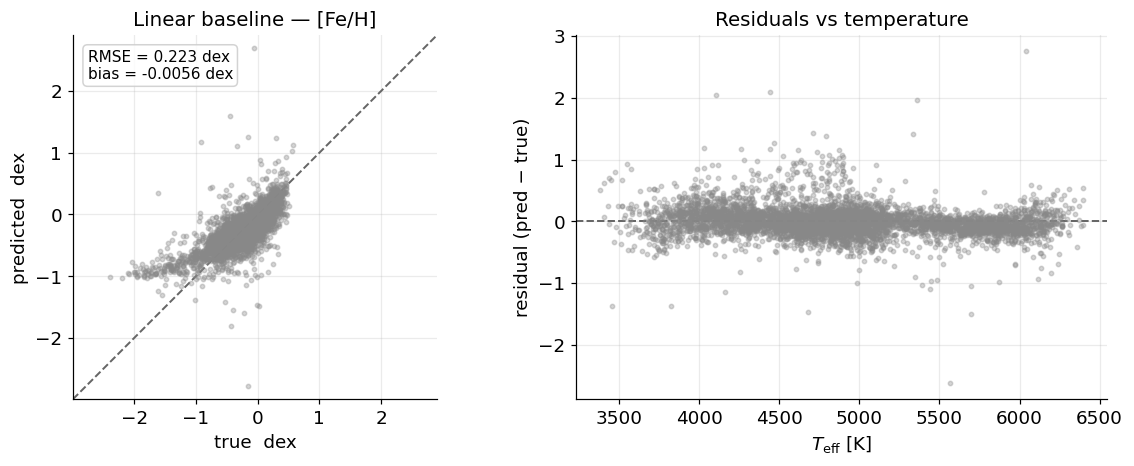

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))

# Left: predicted vs true [Fe/H], with the 1:1 line and an RMSE annotation baked in by the helper.
plot_pred_vs_true(y_test, y_test_pred, ax=axes[0],
                  color=COLORS["linear"], title="Linear baseline — [Fe/H]", units=" dex")

# Right: residuals vs surface temperature, for the held-out TEST stars.
plot_residuals(y_test, y_test_pred, feature=sp["y_test"]["Teff"],
               feature_name=r"$T_\mathrm{eff}$ [K]", ax=axes[1], color=COLORS["linear"])
axes[1].set_title("Residuals vs temperature")
plt.tight_layout()
savefig("nb2_linear_baseline.png")   # poster-ready copy
plt.show()

*Caption: points track the 1:1 line, but the residual band isn't a uniform stripe — its width changes across the data. That uneven spread is exactly what a single RMSE can't tell you, and it's what §3 starts to chase down.*

## 3 · Where does the baseline do best — and worst?

The residual fan in §2.1 hinted that errors aren't uniform. Let's pin down *where*. The framing tool is
the **Kiel diagram** — the `Teff`–`log g` plane astronomers use to place stars (hot on the left,
luminous giants at the top). Coloring each test star by its **absolute error** turns the question "where
is the model trustworthy?" into a picture.

But the Kiel plane only shows two axes. Your target, `[Fe/H]`, is a *third* axis — so we'll also bin the
error directly by metallicity and by gravity. **Let the numbers tell you where it breaks**, rather than
assuming. (This is a quick first pass on the baseline. Tomorrow, in your tuning lab, you'll build the
same map for *your own* tuned model and read it much more closely.)


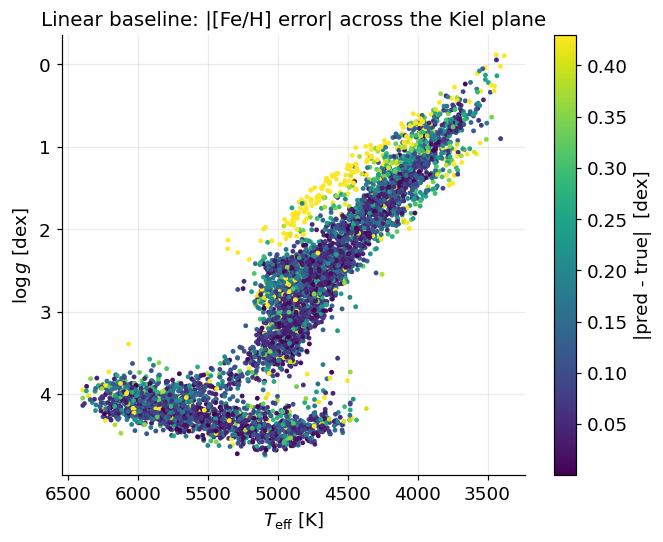

In [8]:
# Absolute [Fe/H] error per TEST star, placed on the Teff-logg plane (the Kiel diagram).
abs_err = np.abs(y_test_pred - y_test)
teff = sp["y_test"]["Teff"].to_numpy()
logg = sp["y_test"]["logg"].to_numpy()
feh  = sp["y_test"]["FeH"].to_numpy()

fig, ax = plt.subplots(figsize=(6.8, 5.2))
sc = ax.scatter(teff, logg, c=abs_err, s=10, cmap="viridis",
                vmax=np.quantile(abs_err, 0.95))   # clip color so a few big errors don't wash it out
ax.invert_xaxis(); ax.invert_yaxis()               # Kiel convention: hot left, giants top
ax.set_xlabel(r"$T_\mathrm{eff}$ [K]"); ax.set_ylabel(r"$\log g$ [dex]")
ax.set_title("Linear baseline: |[Fe/H] error| across the Kiel plane")
fig.colorbar(sc, label="|pred - true|  [dex]")
savefig("nb2_linear_errormap.png")
plt.show()

*Caption: the error isn't uniform across the plane. Don't eyeball it alone — the next cell bins the error by `log g` **and** by `[Fe/H]` so you can read off exactly which stars are hard.*

In [9]:
# Quantify the discovery: average |error| in terciles of log g and of [Fe/H].
def binned_error(values, name, n=3):
    edges = np.quantile(values, np.linspace(0, 1, n + 1)); edges[-1] += 1e-9
    print(f"mean |[Fe/H] error| by {name}:")
    for i in range(n):
        m = (values >= edges[i]) & (values < edges[i + 1])
        print(f"  {name} in [{edges[i]:7.2f}, {edges[i+1]:7.2f}] : "
              f"{abs_err[m].mean():.3f} dex   (n={m.sum()})")

binned_error(logg, "log g")   # low log g = luminous GIANTS; high log g = compact DWARFS
binned_error(feh,  "[Fe/H]")  # low [Fe/H] = METAL-POOR stars

mean |[Fe/H] error| by log g:
  log g in [  -0.12,    2.39] : 0.188 dex   (n=2000)
  log g in [   2.39,    3.47] : 0.112 dex   (n=2000)
  log g in [   3.47,    4.74] : 0.134 dex   (n=2000)
mean |[Fe/H] error| by [Fe/H]:
  [Fe/H] in [  -2.40,   -0.31] : 0.185 dex   (n=2000)
  [Fe/H] in [  -0.31,   -0.05] : 0.111 dex   (n=2000)
  [Fe/H] in [  -0.05,    0.57] : 0.137 dex   (n=2000)


*Caption: read these two tables together. The error is largest for the **lowest-`log g`** stars (luminous giants) and the **lowest-`[Fe/H]`** stars (metal-poor) — the sparse, information-starved corners. That uneven, conditional error is the exact problem next week's uncertainty work tackles, and the map you'll draw for your own model tomorrow.*

## 4 · Save the baseline — your model and Notebooks 3–4 need it

Two things travel forward from today:

- Your **tuning lab** (02a/02b/02c) opens by loading this baseline as *the bar to beat*.
- **Notebooks 3 and 4** don't re-train anything — they **read saved predictions** and a **saved model**.

So we save the baseline two ways, using the project helpers:

1. `save_outputs("linear_preds.npz", ...)` — the predictions and truths on **both** the calibration and
   test splits. (Why save *calibration* predictions? Next week you'll use the calibration residuals to
   size and then *guarantee* uncertainty intervals — a foreshadow of NB3.) The filename and keys are a
   fixed **contract**; don't rename them, or the later notebooks won't find your work:

   > `outputs/linear_preds.npz` with keys `y_cal_true, y_cal_pred, y_test_true, y_test_pred`.

2. `save_model(linear_pipe, "linear")` — the **fitted pipeline itself**, to `models/linear.joblib`. A
   trained model is an experiment result; persisting it means NB3 can load the *exact* model you built
   (no silent refit). This is the bare-bones version of what tools like **MLflow** or **Weights &
   Biases** do for real teams.

The model strings are `"linear"`, and (for your tuning lab) one of `"knn"` / `"rf"` / `"nn"` — note the
neural net is **`"nn"`**, not `"mlp"`.


In [10]:
# Save the baseline predictions on BOTH the calibration and test splits (the NB2->NB3->NB4 contract).
save_outputs(
    "linear_preds.npz",
    y_cal_true =y_cal,
    y_cal_pred =linear_pipe.predict(sp["X_cal"]),    # predictions on the held-out CALIBRATION split
    y_test_true=y_test,
    y_test_pred=linear_pipe.predict(sp["X_test"]),   # predictions on the TEST split
)
print("wrote outputs/linear_preds.npz")

# Save the FITTED pipeline itself, so NB3 can load the exact baseline (no silent refit).
path = save_model(linear_pipe, "linear")
print("wrote", path)

# Sanity check: reload and confirm the schema NB3/NB4 expect.
chk = load_outputs("linear_preds.npz")
print("keys:", sorted(chk.keys()), "| test preds shape:", chk["y_test_pred"].shape)

wrote outputs/linear_preds.npz
wrote /mnt/c/Users/joshs/Dropbox/GitHub/utssrp-2026/models/linear.joblib
keys: ['y_cal_pred', 'y_cal_true', 'y_test_pred', 'y_test_true'] | test preds shape: (6000,)


*Caption: two files written — `outputs/linear_preds.npz` (cal + test predictions and truths) and `models/linear.joblib` (the fitted pipeline). These are the baseline everyone shares; your own tuned model gets saved the same way, with the same keys, in your tuning lab.*

## 5 · The fork — now go tune *your* model

This is where the three of you **diverge**. You've all built and measured the *same* linear baseline;
from here, each of you takes **one** model and tunes it deeply in its own lab. Open **your** notebook
now:

| You are | Your model | Open this notebook | In one sentence |
|---|---|---|---|
| **Student A** | **K-nearest neighbors (KNN)** | **`02a_tune_knn`** | predict a star from the average `[Fe/H]` of its *k* most similar training stars |
| **Student B** | **Random forest (RF)** | **`02b_tune_random_forest`** | average hundreds of decision trees, each on a random slice of the data |
| **Student C** | **Neural network (MLP)** | **`02c_tune_neural_net`** | a flexible function with hidden layers of weights, fit by gradient descent |

A **hyperparameter** is a setting you choose *before* fitting (as opposed to the weights the model
learns *during* fitting). Each lab walks you through the same craft, hands-on, on *your* model:

1. **Read the docstring** and meet your estimator's knobs.
2. **Sweep the main knob by hand and plot** the bias–variance curve (you saw a preview of overfitting in
   §1.3 — now you'll watch the dial).
3. Try the **categorical** knobs, then run a **`GridSearchCV`** and a **`RandomizedSearchCV`**.
4. **Log every run** with `log_experiment(...)`, **save** your best model, and map its errors across the
   Kiel plane — exactly as we did for the baseline in §3, but deeper.

Your linear baseline number (printed in §2) is the bar. Tomorrow's question: *can your model beat it,
and — more interestingly — **where**?*

*References (open your own):*
[KNeighborsRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html) ·
[RandomForestRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html) ·
[MLPRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPRegressor.html).


## Wrap-up · What the team built, and what's next

Together you ran a full supervised pipeline — **preprocess → split → fit → predict → evaluate** — saw
**overfitting** in the wild (a tree with a perfect *training* score and a poor *test* score), measured a
linear **baseline** for `[Fe/H]`, and mapped *where* it's reliable across the Kiel plane. You saved the
baseline to `outputs/` and `models/` so everything downstream can find it.

The cliffhanger is the same one Notebook 1 left: the errors aren't uniform. They pile up on
**metal-poor stars and luminous giants** — the sparse, information-starved corners — so the error *size*
changes across the data. A single number like RMSE can't express that.

- **Today/tomorrow:** open **your** tuning lab and beat the baseline with your own model.
- **Notebook 3** turns point predictions into **intervals** and asks whether they're *honest* — and
  finds the giants and metal-poor stars under-covered.
- **Notebook 4** makes the guarantee *rigorous* with **conformal prediction**, then shows exactly where
  the guarantee still strains.

Bring your baseline number and one sentence — "the hard region is …" — to the debrief.

---

### Further reading

- **scikit-learn — Pipelines (chaining estimators):**
  https://scikit-learn.org/stable/modules/compose.html#pipeline — why a Pipeline prevents data leakage.
- **scikit-learn — Cross-validation: evaluating estimator performance:**
  https://scikit-learn.org/stable/modules/cross_validation.html — the honest way to judge a model.
- **scikit-learn — Underfitting vs. overfitting (worked example):**
  https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html
- **scikit-learn — Decision Trees (user guide):**
  https://scikit-learn.org/stable/modules/tree.html — the over-flexible model from §1.3.
- **scikit-learn — LinearRegression (API):**
  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- **The paper behind the data — Laroche & Speagle 2025 (arXiv:2404.07316):**
  https://arxiv.org/abs/2404.07316 — why XP chemical information is cleaner for cool stars and weakens
  toward hot stars (the physical root of the heteroscedastic `[Fe/H]` error).
- **Kiel / Hertzsprung–Russell diagram (background):**
  https://en.wikipedia.org/wiki/Hertzsprung%E2%80%93Russell_diagram
